The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


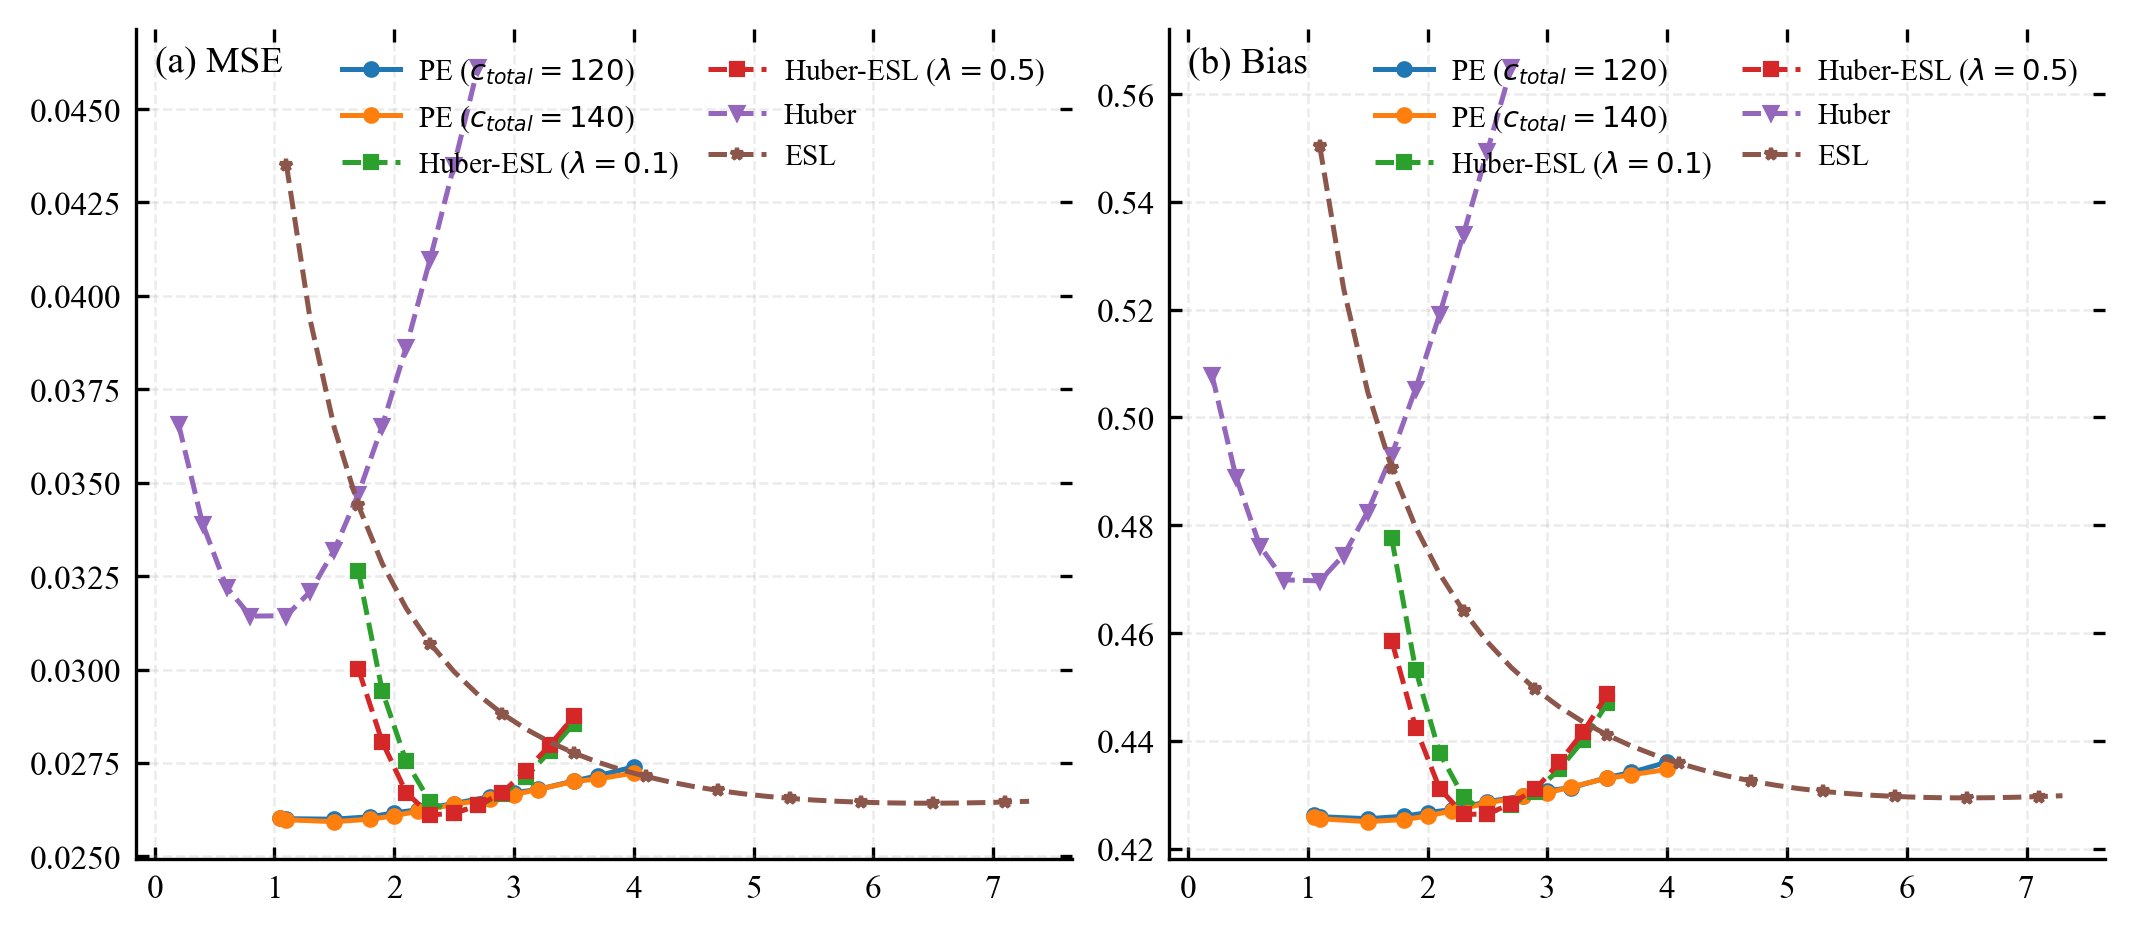

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.dpi": 300,
})

df_prop2 = pd.read_csv(r"C:/Users/apple/Desktop/modified_huber/diff_power_results_totalnode120.csv")
df_prop4 = pd.read_csv(r"C:/Users/apple/Desktop/modified_huber/diff_power_results_totalnode140.csv")
df_hubesl1  = pd.read_csv(r"C:/Users/apple/Desktop/modified_huber/diff_tau_esl_huberlambda0.1.csv")
df_hubesl2  = pd.read_csv(r"C:/Users/apple/Desktop/modified_huber/diff_tau_esl_huberlambda0.5.csv")
df_Huber  =pd.read_csv(r"C:/Users/apple/Desktop/modified_huber/diff_tau_huber.csv")
df_esl  =pd.read_csv(r"C:/Users/apple/Desktop/modified_huber/diff_tau_esl.csv")
def polish_axes(ax):
    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.25)
    ax.tick_params(direction="in", top=True, right=True, length=3, width=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # 不要轴名字：确保 label 被清空
    ax.set_xlabel("")
    ax.set_ylabel("")

def plot_series(ax, x, y, label, ls="-", marker=None):
    n = len(x)
    markevery = max(n // 10, 1)
    ax.plot(x, y, label=label, linestyle=ls, marker=marker, markersize=3, markevery=markevery)

fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

# (a) MSE
ax = axes[0]
plot_series(ax, df_prop2["power"], df_prop2["mse"], r"PE ($c_{total}=120$)", ls="-",  marker="o")
plot_series(ax, df_prop4["power"], df_prop4["mse"], r"PE ($c_{total}=140$)", ls="-",  marker="o")
plot_series(ax, df_hubesl1["tau"], df_hubesl1["mse"],   r"Huber-ESL ($\lambda=0.1$)", ls="--", marker="s")
plot_series(ax, df_hubesl2["tau"], df_hubesl2["mse"],   r"Huber-ESL ($\lambda=0.5$)", ls="--", marker="s")
plot_series(ax, df_Huber["tau"], df_Huber["mse"],   r"Huber", ls="--", marker="v")
plot_series(ax, df_esl["tau"], df_esl["mse"],   r"ESL", ls="--", marker="*")
ax.text(0.02, 0.98, "(a) MSE", transform=ax.transAxes, va="top", ha="left")
ax.legend(frameon=False, ncol=2, handlelength=2.0, columnspacing=1.0, handletextpad=0.6)
polish_axes(ax)

# (b) Bias
ax = axes[1]
plot_series(ax, df_prop2["power"], df_prop2["bias"], r"PE ($c_{total}=120$)", ls="-",  marker="o")
plot_series(ax, df_prop4["power"], df_prop4["bias"], r"PE ($c_{total}=140$)", ls="-",  marker="o")
plot_series(ax, df_hubesl1["tau"], df_hubesl1["bias"],   r"Huber-ESL ($\lambda=0.1$)", ls="--", marker="s")
plot_series(ax, df_hubesl2["tau"], df_hubesl2["bias"],   r"Huber-ESL ($\lambda=0.5$)", ls="--", marker="s")
plot_series(ax, df_Huber["tau"], df_Huber["bias"],   r"Huber", ls="--", marker="v")
plot_series(ax, df_esl["tau"], df_esl["bias"],   r"ESL", ls="--", marker="*")
ax.text(0.02, 0.98, "(b) Bias", transform=ax.transAxes, va="top", ha="left")
ax.legend(frameon=False, ncol=2, handlelength=2.0, columnspacing=1.0, handletextpad=0.6)
polish_axes(ax)

#plt.show()
plt.savefig("exmap3.eps", dpi=300, bbox_inches="tight")